# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# file paths for both data sets
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# load your chosen dataset and save it to df
df = pd.read_csv(airbnb_filename)

df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the Airbnb NYC Listings Data (airbnbListingsData.csv)
2. My label is price_category which classifies each listing as either "high" (at or above the 75th percentile of price) or "low" (below the 75th percentile). I converted this to a binary numeric label (0 = low, 1 = high) during data preparation. I'm predicting whether a given Airbnb listing will be high-priced based on its characteristics.
3. Based on my initial review of the data, I plan to use features related to listing attributes (accommodates, bathrooms, bedrooms, beds, room_type), location (neighbourhood_group_cleansed), host characteristics (host_is_superhost, host_listings_count, host_response_rate, host_acceptance_rate), and review scores (review_scores_rating), etc. I plan to exclude free-text fields like name, description, host_about, and neighborhood_overview, since they aren't structured for this kind of model without additional NLP processing.
4. This problem matters because it can help Airbnb hosts better understand the factors that contribute to a listing having a higher price. An organization could use this model to help clients (Airbnb hosts) make more informed decisions about their listings by identifying features, such as room type, location, and review scores, that are most associated with higher pricing. This gives hosts concrete guidance on where to focus their efforts, which can help them increase their listings competitiveness, attract more guests, and grow their revenue.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

In [3]:
df.groupby('price_category').size()

price_category
high     7237
low     20785
dtype: int64

In [4]:
df['price_category'].value_counts()

low     20785
high     7237
Name: price_category, dtype: int64

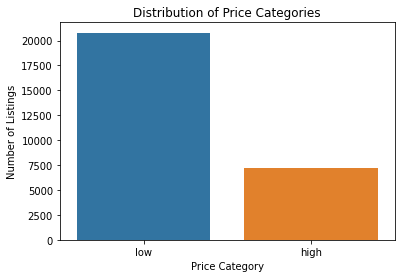

In [5]:
# class balance visualization
sns.countplot(data=df, x='price_category')
plt.title("Distribution of Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Number of Listings")
plt.show()

In [6]:
df['price_category'].value_counts(normalize=True)

low     0.741739
high    0.258261
Name: price_category, dtype: float64

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [7]:
# look at first few rows
df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


In [8]:
# data types
df.dtypes

name                                             object
description                                      object
neighborhood_overview                            object
host_name                                        object
host_location                                    object
host_about                                       object
host_response_rate                              float64
host_acceptance_rate                            float64
host_is_superhost                                  bool
host_listings_count                             float64
host_total_listings_count                       float64
host_has_profile_pic                               bool
host_identity_verified                             bool
neighbourhood_group_cleansed                     object
room_type                                        object
accommodates                                      int64
bathrooms                                       float64
bedrooms                                        

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28022 entries, 0 to 28021
Data columns (total 51 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   name                                          28017 non-null  object 
 1   description                                   27452 non-null  object 
 2   neighborhood_overview                         18206 non-null  object 
 3   host_name                                     28022 non-null  object 
 4   host_location                                 27962 non-null  object 
 5   host_about                                    17077 non-null  object 
 6   host_response_rate                            16179 non-null  float64
 7   host_acceptance_rate                          16909 non-null  float64
 8   host_is_superhost                             28022 non-null  bool   
 9   host_listings_count                           28022 non-null 

In [10]:
# missing values
df.isnull().sum()

name                                                5
description                                       570
neighborhood_overview                            9816
host_name                                           0
host_location                                      60
host_about                                      10945
host_response_rate                              11843
host_acceptance_rate                            11113
host_is_superhost                                   0
host_listings_count                                 0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
neighbourhood_group_cleansed                        0
room_type                                           0
accommodates                                        0
bathrooms                                           0
bedrooms                                         2918
beds                        

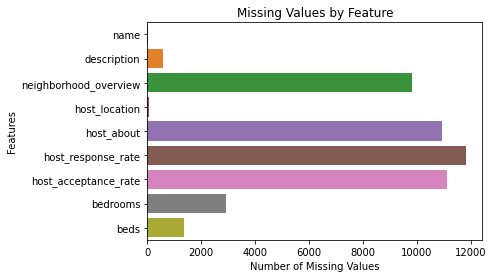

In [11]:
# missing values data visualization
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

sns.barplot(x=missing_values.values, y=missing_values.index)
plt.title("Missing Values by Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Features")
plt.show()

# removing name, description, neighborhood_overview, host_location, and host_about bc they're text-based
# keeping host_response_rate, host_acceptance_rate, bedrooms, and bed bc it contains useful info. missing values will be filled using the median.

In [12]:
# summary statistics
df.describe()

,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications
count,16179.000000,16909.000000,28022.000000,28022.000000,28022.000000,28022.000000,25104.000000,26668.000000,28022.000000,28022.000000,...,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000
mean,0.906901,0.791953,14.554778,14.554778,2.874491,1.142174,1.329708,1.629556,154.228749,18.689387,...,4.814300,4.808041,4.750393,4.647670,9.581900,5.562986,3.902077,0.048283,1.758325,5.169510
std,0.227282,0.276732,120.721287,120.721287,1.860251,0.421132,0.700726,1.097104,140.816605,25.569151,...,0.438603,0.464585,0.415717,0.518023,32.227523,26.121426,17.972386,0.442459,4.446143,2.028497
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,29.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000,1.000000
25%,0.940000,0.680000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,70.000000,2.000000,...,4.810000,4.810000,4.670000,4.550000,1.000000,0.000000,0.000000,0.000000,0.130000,4.000000
50%,1.000000,0.910000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,115.000000,30.000000,...,4.960000,4.970000,4.880000,4.780000,1.000000,1.000000,0.000000,0.000000,0.510000,5.000000
75%,1.000000,1.000000,3.000000,3.000000,4.000000,1.000000,1.000000,2.000000,180.000000,30.000000,...,5.000000,5.000000,5.000000,5.000000,3.000000,1.000000,1.000000,0.000000,1.830000,7.000000
max,1.000000,1.000000,3387.000000,3387.000000,16.000000,8.000000,12.000000,21.000000,1000.000000,1250.000000,...,5.000000,5.000000,5.000000,5.000000,421.000000,308.000000,359.000000,8.000000,141.000000,13.000000


In [13]:
# host_listings_count confirmed redundancy
(df['host_listings_count'] == df['host_total_listings_count']).all()

# removing host_total_listings_count bc there is a duplicate

True

In [14]:
# checking range of two features before handling outliers
df[['minimum_nights', 'host_listings_count']].describe()

# checking these features for outliers bc of their unusal large max values and right-skewed dist.

,minimum_nights,host_listings_count
count,28022.000000,28022.000000
mean,18.689387,14.554778
std,25.569151,120.721287
min,1.000000,0.000000
25%,2.000000,1.000000
50%,30.000000,1.000000
75%,30.000000,3.000000
max,1250.000000,3387.000000


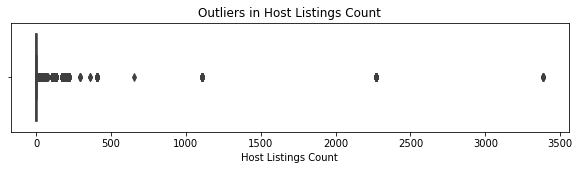

In [15]:
# host listings outliers data visualization (boxplot)
plt.figure(figsize=(10,2))
sns.boxplot(data=df, x='host_listings_count')
plt.title("Outliers in Host Listings Count")
plt.xlabel('Host Listings Count')
plt.show()

In [16]:
# outlier detection (IQR) for host_listings_count
Q1_h = df['host_listings_count'].quantile(0.25)
Q3_h = df['host_listings_count'].quantile(0.75)
IQR_h = Q3_h - Q1_h
lower_bound_h = Q1_h - 1.5 * IQR_h
upper_bound_h = Q3_h + 1.5 * IQR_h

print("Q1:", Q1_h)
print("Q3:", Q3_h)
print("IQR:", IQR_h)
print("Lower bound:", lower_bound_h)
print("Upper bound:", upper_bound_h)

# checking number of outliers outside these bounds
outliers = ((df['host_listings_count'] < lower_bound_h) | (df['host_listings_count'] > upper_bound_h)).sum()
print("Number of outliers:", outliers)

Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 4024


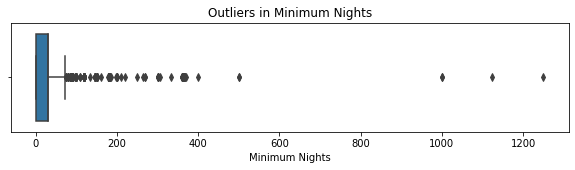

In [17]:
# minimum nights outliers data visualization (boxplot)
plt.figure(figsize=(10,2))
sns.boxplot(data=df, x='minimum_nights')
plt.title("Outliers in Minimum Nights")
plt.xlabel('Minimum Nights')
plt.show()

In [18]:
# outlier detection (IQR) for minimum_nights
Q1 = df['minimum_nights'].quantile(0.25)
Q3 = df['minimum_nights'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# checking number of outliers outside these bounds
outliers = ((df['minimum_nights'] < lower_bound) | (df['minimum_nights'] > upper_bound)).sum()
print("Number of outliers:", outliers)

Q1: 2.0
Q3: 30.0
IQR: 28.0
Lower bound: -40.0
Upper bound: 72.0
Number of outliers: 281


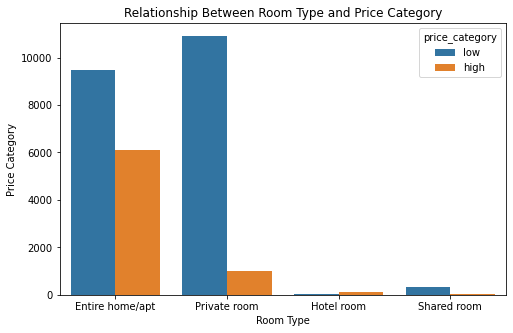

In [19]:
# room type (feature) vs price category (label)
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='room_type', hue='price_category')
plt.title("Relationship Between Room Type and Price Category")
plt.xlabel("Room Type")
plt.ylabel("Price Category")
plt.show()

# keeping room_type bc it shows a relationship w the target var

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

The label showed clear class imbalance: about 74% of listings were "low" price and only 26% were "high" price. This imbalance meant I needed to be careful with model evaluation, since accuracy alone could be misleading. This led me to use F1 score alongside accuracy and to try class_weight = 'balanced' during hyperparameter tuning.

A lot of the columns had significant missing values, most notably host_about, neighborhood_overview, host_response_rate, and host_acceptance rate, along with smaller amount of missing data in bedrooms and beds. I plan to drop the free-text columns (name, description, neighborhood_overview, host_about, host_location). For bedrooms, beds, host_response_rate, and host_acceptance_rate, I plan to fill the missing values with the median, since these are numeric features with informative values worth keeping. I also think using the median imputation avoids being skewed by outliers.

I also found that host_listings_count and host_total_listings_count were exact duplicates of each other, so I removed the redundant column. To continue, host_listings_count and minimum_nights both showed strong distributions with extreme outliers (for example, a max of 3,387 for host listings count and 1,250 for minimum nights), which I later addressed by winsorizing these using the IQR method.

Finally, I visualized room_type against price_category. I found that entire homes/apartments frequently fall into the high-price category compared to private or shared rooms. This confirmed that room_type could be a useful feature to keep and one-hot encode for modeling.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. The data was collected from NYC Airbnb listings so it reflects existing housing and neighborhood patterns in the city. This includes areas historically affected by discriminatory housing practices. neighborhood_group_cleansed could act as a proxy for socioeconomic status. I chose to keep neighborhood_group_cleansed anyway, since location is an expected driver of Airbnb pricing, but this tradeoff is worth acknowledging since it means the model's predictions will partly reflect existing geographic disparities.
2. Hosts in lower-income or historically marginalized neighborhoods could be predicted as "low price", even if their listings are competitively priced because the model associates their neighborhood with lower prices. It could also harm smaller or newer hosts since they usually have fewer reviews and less pricing history for the model to learn from. If the model underprices their listing, they could lose income they'd otherwise be able to charge. To continue, guests can also be harmed since pricing recommendations may not reflect a listing's actual value. Therefore, a listing could end up being overpriced and reduce affordability for guests looking for reasonably priced options.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [20]:
# selecting appropriate features and removing irrelevant features
df = df.drop(columns=[
    'price',
    'host_total_listings_count',
    'name', 'host_name', 'host_location',
    'host_about', 'neighborhood_overview', 'description',
    'amenities'
])

df.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_group_cleansed,room_type,accommodates,bathrooms,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,0.80,0.17,True,8.0,True,True,Manhattan,Entire home/apt,1,1.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,0.09,0.69,True,1.0,True,True,Brooklyn,Entire home/apt,3,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,1.00,0.25,True,1.0,True,True,Brooklyn,Entire home/apt,4,1.5,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,1.00,1.00,True,1.0,True,True,Manhattan,Private room,2,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,NaN,NaN,True,1.0,True,True,Manhattan,Private room,1,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


In [21]:
# checking how much missing values exist
df[['bedrooms', 'beds', 'host_response_rate', 'host_acceptance_rate']].isnull().sum()

bedrooms                 2918
beds                     1354
host_response_rate      11843
host_acceptance_rate    11113
dtype: int64

In [22]:
# converting boolean columns to numeric (0/1) so they can be used in scaling and modeling
bool_columns = df.select_dtypes(include='bool').columns
df[bool_columns] = df[bool_columns].astype(int)

In [23]:
# fill missing values with each column's median
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['beds'] = df['beds'].fillna(df['beds'].median())
df['host_response_rate'] = df['host_response_rate'].fillna(df['host_response_rate'].median())
df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].median())

# confirming missing values have been filled
print(df[['bedrooms', 'beds', 'host_response_rate', 'host_acceptance_rate']].isnull().sum())

bedrooms                0
beds                    0
host_response_rate      0
host_acceptance_rate    0
dtype: int64


In [24]:
# performing feature engineering techniques such as one-hot encoding on categorical feature (room_type)
df['room_type'].unique()
df = pd.get_dummies(df, columns=['room_type'], drop_first=True)

df.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_group_cleansed,accommodates,bathrooms,bedrooms,...,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,0.80,0.17,1,8.0,1,1,Manhattan,1,1.0,1.0,...,3,3,0,0,0.33,9,low,0,0,0
1,0.09,0.69,1,1.0,1,1,Brooklyn,3,1.0,1.0,...,1,1,0,0,4.86,6,low,0,0,0
2,1.00,0.25,1,1.0,1,1,Brooklyn,4,1.5,2.0,...,1,1,0,0,0.02,3,high,0,0,0
3,1.00,1.00,1,1.0,1,1,Manhattan,2,1.0,1.0,...,1,0,1,0,3.68,4,low,0,1,0
4,1.00,0.91,1,1.0,1,1,Manhattan,1,1.0,1.0,...,1,0,1,0,0.87,7,low,0,1,0


In [25]:
# decided to keep neighbourhood_group_cleansed_group_cleansed
# performing feature engineering techniques such as one-hot encoding on categorical feature (neighborhood_group_cleansed)
df['neighbourhood_group_cleansed'].unique()
df = pd.get_dummies(df, columns=['neighbourhood_group_cleansed'], drop_first=True)

df.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,accommodates,bathrooms,bedrooms,beds,...,reviews_per_month,n_host_verifications,price_category,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island
0,0.80,0.17,1,8.0,1,1,1,1.0,1.0,1.0,...,0.33,9,low,0,0,0,0,1,0,0
1,0.09,0.69,1,1.0,1,1,3,1.0,1.0,3.0,...,4.86,6,low,0,0,0,1,0,0,0
2,1.00,0.25,1,1.0,1,1,4,1.5,2.0,2.0,...,0.02,3,high,0,0,0,1,0,0,0
3,1.00,1.00,1,1.0,1,1,2,1.0,1.0,1.0,...,3.68,4,low,0,1,0,0,1,0,0
4,1.00,0.91,1,1.0,1,1,1,1.0,1.0,1.0,...,0.87,7,low,0,1,0,0,1,0,0


In [26]:
# checking current label value
print(df['price_category'].unique())

# encode target variable: low = 0, high = 1
df['price_category'] = df['price_category'].map({'low': 0, 'high': 1})
print(df['price_category'].unique())
print(df['price_category'].value_counts())

['low' 'high']
[0 1]
0    20785
1     7237
Name: price_category, dtype: int64


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I removed some columns before modeling:
- price (could cause data leakage)
- host_total_listings_count (an exact duplicate of host_listings_count, confirmed during EDA)
- name, description, neighborhood_overview, host_name, host_location, host_about, amenities (free-text features)

I filled missing values using the median for features including bedrooms, beds, host_response_rate, and host_acceptance_rate because it will help avoid a large or small imputed value to be present in the data. This is important because we don't want these values to distort the feature's relationship with the label.

I converted all boolean columns (host_is_superhost, host_has_profile_pic, host_identity_verified, has_availability, instant_bookable) to numeric 0/1 values so they could be used directly in scaling and modeling since scikit-learn model expects a numerical input.

I one-hot encoded two categorical features (room_type and neighbourhood_group_cleansed). Both features showed a relationship during EDA, so I kept them instead of dropping them, and used drop_first = True to avoid redundant columns.

Finally, I did not winsorize the outliers that I found in host_listings_count and minimum_nights during this data preparation step. Instead, I'm planning to handle that in Part 5 (Train, Test, Evaluate), since I chose logistic regression as my model. I'll also apply feature scaling (StandardScaler) in Part 5. I will use class_weight='balanced' to address the class imbalance I identified during EDA.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [27]:
# create labeled examples from the dataset
y = df['price_category']
X = df.drop(columns=['price_category'])

In [28]:
# create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

X_train = X_train.copy()
X_test = X_test.copy()

# winzoring outlier features using IQR
columns = ['host_listings_count', 'minimum_nights']

for col in columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    X_train.loc[X_train[col] < lower_bound, col] = lower_bound
    X_train.loc[X_train[col] > upper_bound, col] = upper_bound
    
    X_test.loc[X_test[col] < lower_bound, col] = lower_bound
    X_test.loc[X_test[col] > upper_bound, col] = upper_bound
    
    print(f"{col}: lower={lower_bound:.2f}, upper={upper_bound:.2f}")

# then scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

host_listings_count: lower=-2.00, upper=6.00
minimum_nights: lower=-40.00, upper=72.00


In [29]:
X_train[['host_listings_count', 'minimum_nights']].describe()

,host_listings_count,minimum_nights
count,22417.000000,22417.000000
mean,2.128563,17.750413
std,1.963300,14.905087
min,0.000000,1.000000
25%,1.000000,2.000000
50%,1.000000,30.000000
75%,3.000000,30.000000
max,6.000000,72.000000


In [30]:
X_test[['host_listings_count', 'minimum_nights']].describe()

,host_listings_count,minimum_nights
count,5605.000000,5605.000000
mean,2.151472,17.370919
std,1.992151,14.889972
min,0.000000,1.000000
25%,1.000000,2.000000
50%,1.000000,30.000000
75%,3.000000,30.000000
max,6.000000,72.000000


In [31]:
# train, test and evaluate your model
model_default = LogisticRegression(max_iter=1000)
model_default.fit(X_train_scaled, y_train)

y_pred = model_default.predict(X_test_scaled)

acc_default = accuracy_score(y_test, y_pred)
f1_default = f1_score(y_test, y_pred, average='binary')

print("Default Accuracy:", acc_default)
print("Default F1 Score:", f1_default)

Default Accuracy: 0.8233719892952721
Default F1 Score: 0.6153846153846153


In [32]:
# perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
cs = [10**i for i in range(-5,5)]
param_grid = {'C': cs, 'class_weight': [None, 'balanced']}

model = LogisticRegression(max_iter=1000)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='f1',cv=5)

grid.fit(X_train_scaled, y_train)

print("Best hyperparameters:", grid.best_params_)
print("Best CV F1 score:", grid.best_score_)

Best hyperparameters: {'C': 0.1, 'class_weight': 'balanced'}
Best CV F1 score: 0.6509752072809106


In [33]:
best_C = grid.best_params_['C']
best_C

0.1

In [34]:
best_class_weight = grid.best_params_['class_weight']

In [35]:
# train, test and evaluate a final version of your model using the optimal hyperparameter values.
final_model = LogisticRegression(max_iter=1000, C=best_C, class_weight=best_class_weight)
final_model.fit(X_train_scaled, y_train)

y_pred_final = final_model.predict(X_test_scaled)

acc_final = accuracy_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final, average='binary')

print("Final Accuracy:", acc_final)
print("Final F1 Score:", f1_final)

Final Accuracy: 0.783407671721677
Final F1 Score: 0.665380374862183


In [36]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_final))

[[3184  940]
 [ 274 1207]]


In [37]:
# interpret model's outputs
coefficients = pd.Series(final_model.coef_[0], index=X.columns)
print(coefficients.sort_values())

room_type_Private room                         -0.921610
minimum_nights                                 -0.613082
review_scores_value                            -0.307068
number_of_reviews                              -0.258713
review_scores_checkin                          -0.198220
calculated_host_listings_count                 -0.187179
room_type_Shared room                          -0.171052
availability_60                                -0.152858
neighbourhood_group_cleansed_Staten Island     -0.129810
availability_365                               -0.101175
calculated_host_listings_count_shared_rooms    -0.098232
calculated_host_listings_count_entire_homes    -0.091361
review_scores_communication                    -0.090816
minimum_maximum_nights                         -0.089857
minimum_minimum_nights                         -0.077793
maximum_nights                                 -0.067910
number_of_reviews_l30d                         -0.042367
reviews_per_month              

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose logistic regression because this is a binary classification problem (predicting "high" vs "low" price). It produces interpretable coefficients that show how each feature relates to the odds of a listing being high-priced. This fits the business goal of giving hosts clear guidance on which features to focus on to price their listing competitively.
2. The default model had higher accuracy (0.823) but a lower F1 score (0.615) due to class imbalance. Grid search found C=0.1 and class_weight='balanced' improved F1 to 0.665, through accuracy dropped slightly to 0.783. This is a reasonable tradeoff because F1 matters more for this imbalanced problem.
3. neighbourhood_group_cleansed_Manhattan (1.19) and accomodates (0.72) were the strongest positive predictors of high price, while room_type_Private room (-0.92) and minimum_nights (-0.61) were the strongest negative predictors. The confusion matrix shows the model catches most high-priced listings (1207 true positives) but also produces a good amount of false positives (940).
4. Yeah. There are some fairness or ethical concerns with my model. The model relies on borough as a predictor which could reinforce existing geographic and socioeconomic disparities in NYC housing. The hosts in lower coefficient boroughs could be undervalued, while false positives elsewhere could mislead hosts into overpricing.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [38]:
# scale your data for the neural network

# create the scaler
scaler = StandardScaler()

# fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [39]:
# get the number of features in your training data
n_features = X_train_scaled.shape[1]

# create the neural network model
nn_model = keras.Sequential()

# create the input layer and add the input layer to the 'nn_model' object
nn_model.add(keras.layers.InputLayer(input_shape=(n_features,)))

# create the hidden layers and add the hidden layers to the 'nn_model' object
# decision: how many layers? how many units? what activation function?
# add a comment explaining your choices.
nn_model.add(keras.layers.Dense(64, activation='relu'))
nn_model.add(keras.layers.Dense(32, activation='relu'))

# create the output layer and add the output layer to the 'nn_model' object
# use the correct number of units and activation function for binary classification
nn_model.add(keras.layers.Dense(1, activation='sigmoid'))

# print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                3008      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 33        
Total params: 5,121
Trainable params: 5,121
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [40]:
# decision: what learning rate will you use?
# i chose a learning rate of 0.01 cuz its a common default for sgd
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [41]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [42]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [43]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [44]:
# decision: How many epochs?
# i chose 100 epochs cuz i wanted to observe if there was an overfitting pattern

t0 = time.time() # start time

num_epochs = 100 

history = nn_model.fit(X_train_scaled, y_train, epochs=num_epochs, validation_split=0.2, 
                       callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)], verbose=0)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [10/ 100], Loss: 0.3472, Accuracy: 0.8442, Val_loss: 0.3490, Val_accuracy: 0.8421
Epoch [20/ 100], Loss: 0.3301, Accuracy: 0.8522, Val_loss: 0.3388, Val_accuracy: 0.8455
Epoch [30/ 100], Loss: 0.3192, Accuracy: 0.8583, Val_loss: 0.3357, Val_accuracy: 0.8477
Epoch [40/ 100], Loss: 0.3108, Accuracy: 0.8619, Val_loss: 0.3355, Val_accuracy: 0.8504
Epoch [50/ 100], Loss: 0.3026, Accuracy: 0.8648, Val_loss: 0.3368, Val_accuracy: 0.8533
Epoch [60/ 100], Loss: 0.2957, Accuracy: 0.8673, Val_loss: 0.3371, Val_accuracy: 0.8533
Epoch [70/ 100], Loss: 0.2895, Accuracy: 0.8704, Val_loss: 0.3416, Val_accuracy: 0.8501
Epoch [80/ 100], Loss: 0.2841, Accuracy: 0.8738, Val_loss: 0.3451, Val_accuracy: 0.8486
Epoch [90/ 100], Loss: 0.2787, Accuracy: 0.8778, Val_loss: 0.3497, Val_accuracy: 0.8432
Epoch [100/ 100], Loss: 0.2744, Accuracy: 0.8791, Val_loss: 0.3493, Val_accuracy: 0.8466
Elapsed time: 76.75s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



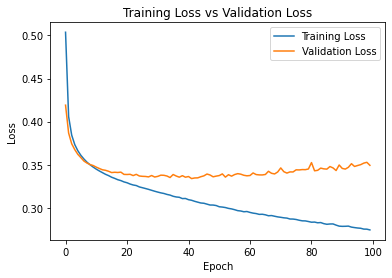

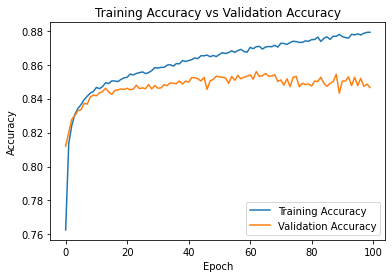

In [45]:
# plot training loss and validation loss over epochs
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.show()

# plot training accuracy and validation accuracy over epochs
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [46]:
# generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

y_pred_prob_nn = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_prob_nn > 0.5).astype(int)

In [47]:
# compute accuracy and F1 score for the neural network and print the results

acc_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn, average='binary')

print("NN Accuracy: ", acc_nn)
print("NN F1 Score: ", f1_nn)

NN Accuracy:  0.8453166815343444
NN F1 Score:  0.6939639957642075


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I use two hidden layers with 64 and 32 units, both with relu activation, narrowing toward the single sigmoid output neuron needed for binary classification. I chose SGD with a learning rate of 0.01 because its a common default/middle ground for speed and stability. I trained for 100 epochs to give the model enough time to produce a clear training curve and also to observe if there are any patterns of overfitting.
2. My training curves showed signs of overfitting. The validation loss decreased until around epoch 40, then slowly increased through epoch 100, while training loss kept decreasing the whole time. Validation accuracy peaked around epoch 50-60 and declined slightly afterward, even as training accuracy kept increasing. This suggests the model is overfitting to the training data during training.
3. On the test set, my neural network got an accuracy of 0.845 and an F1 score of 0.694. I was suprised because the test results were actually my best results in the entire notebook. It outperformed both my earlier training run and my tuned logistic regression model (accuracy 0.783, F1 0.665). I thought it would have worse performance because the training accuracy and validation accuracy over epochs showed some overfitting.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [48]:
# build a side-by-side comparison of your two models using the metric variables

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [acc_final, f1_final],
    'Neural Network': [acc_nn, f1_nn]
})

print(results.to_string(index=False))

   Metric  Logistic Regression  Neural Network
 Accuracy             0.783408        0.845317
 F1 Score             0.665380        0.693964


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. The nueral network outperformed logistic regression on both metrics. The accuracy improved from 0.783 to 0.845, and F1 score improved from 0.665 to 0.694.
2. I don't think the performance gain justified the added complexity for this problem. I say this because the F1 score only improved by about 3 points, but the neural network took much longer (77 seconds) to train and lost the clear coefficients that made logistic regression easy to explain to hosts.
3. I would recommend deploying the logistic regression model. The business brief is about helping hosts understand why a listing is priced a certain way, and I think that logistic regressions coefficients give more clear insights than nueral networks.
4. If I had more time, I would experiment with different architectures. For example, I want to try a wider first hidden layer, adding a third hidden layer, or testing different activation functions.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used Claude at specific points where I need clarification on conceptual concepts. I made a choice not to use it for parts of the workflow I already understood, like basic data cleaning and the initial exploratory analysis. I used Claude to think through outlier detection while I was preparing data (I recalled IQR from module 2.4 and used Claude to confirm my reasoning on applying it to my dataset to detect outliers). I also used Claude to help me understand why and how to address class imbalance using class_weight='balanced' and the F1 score.
2. The most challenging part was understanding why accuracy could be misleading and how to properly address it. I already knew accuracy alone wasn't reliable given the class imbalance found during EDA, but I didn't fully understand why F1 was the better metric or how class_weight='balanced' worked until I walked through it with Claude.
3. I verified my work by talking through my reasoning with my fellow peers during lab sessions. We compared approaches and caught mistakes the other could have missed on their own. I asked my professor or TAs directly about anything I was unsure of whenever they visited our lab breakout rooms, especially places where I wanted a second opinion (for example, my Professor recommended I winsorize the features with outliers instead of dropping the features because it could still contain useful data).
4. Next time, I'd take notes as I go instead of reconstructing my reasoning afterward.